# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### Общая информация

Дата выдачи: 23.02.2026

Мягкий дедлайн: 12.03.2026 23:59MSK

Жесткий дедлайн: 16.03.2026 23:59MSK

### О задании

В данном задании вы познакомитесь с базовыми подходами для создания новых признаков в табличном машинном обучении. Вам понадобится подумать над тем, зачем мы делаем те или иные преобразования, научиться принимать решения, дающие наилучшие результаты, и узнать, как реализовывать их при помощи библиотек

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за эту часть — 6 баллов. Детальнее про оценивание — в самом конце ноутбука.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-03-base-Username.ipynb**, где Username — ваша фамилия.

### **Сетап**

<img style="float: right; padding-right:15px; padding-bottom:10px" src="https://i.postimg.cc/26KqqSb2/pomoika2.png" height=300px width=200px alt="Pomoika 2">
    
В этом домашнем задании мы будем работать с задачей классификации, но сконцентрируемся на том, что приносит не меньшую пользу, чем сами модели — замешиванию данных.

Целевая метрика уже выбрана за нас: мы будем считать $\text{ROC-AUC}$, но не простой, а коэффициент Джини:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

Конечная цель данного мероприятия — собрать пайплайн машинного обучения от и до, начиная с предобработки данных, заканчивая оптимизацией. При желании это можно доделать до целого пет-проекта, особенно если добавить сбор данных и деплой модели, но в дз этого не будет :(.

Цель конкретно базового ноутбука — познакомить вас с основными преобразованиями и собрать солидный фундамент для преобразований посложнее. 

In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

У вас на руках (на Kaggle) датасет по широко известной в неузких кругах видеоигре Dota 2, скачанный через OpenDota API и заботливо анонимизированный. Если вы не знакомы с игрой — ничего страшного, все необходимое для заданий в базовой части мы подробно опишем.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов (например, чтобы делать ставки на спорт, осуждаем?). Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

#### 📌 **Важнейшее замечание**

Предполагается, что у вас уже сложилось понимание:
- как крутить и вертеть данные, чтобы фиты делались твёрдо, трансформы ложились чётко, шейпы датафреймов стакались и нужные джойны джойнились;
- как рисовать читаемые графики;
- как проверять качество модели;

Пожалуйста, следите за этим очень-очень внимательно, иначе рискуете получить штраф и всеобщее порицание в нашем уютном МО-1 чатике (хотя, у этого есть плюсы).

Если возникнут вопросы по игровой части — **не стесняйтесь** спрашивать, гуглить, обращаться к GPT или, прости Господи, дотерам. Знание области — важнейшая составляющая хорошего фича инжиниринга

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Для лучшего понимания, в голубеньких пунктах будет небольшое <font color="#647cb8">**обоснование**</font> того, зачем вообще делается то или иное преобразование (в колабе придётся включать интуицию, там не работает HTML). Вы можете её скипнуть, если всё понятно и без этого

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

В пунктах с розоватой, как у всеми любимого Pudge, расцветкой мы попросим вас написать <font color="#f68c9d">**Ответ**</font> на <font color="#f68c9d">**Вопрос**</font> или <font color="#f68c9d">**рефлексию**</font>, которая должна направить вашу мысль о том, как варить фичи, в нужном направлении. Уметь аргументировать свою точку зрения важно не менее

Пожалуйста, даже если вы уже прожжённый дед инсайд и дата-сайентист 14 уо, всё равно <font color="#f68c9d">**порефлексируйте**</font>. Количество потерянных нервных клеток и ваш успех на соревновании напрямую зависят от базовой предобработки.
Вы **можете** писать <font color="#f68c9d">**её**</font> ёмко, но только если **знаете** ответ

</div>

<div style="border-left: 5px solid #cb9255; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(200, 156, 105, 0.05);">

<font>По ходу домашки вам придётся делать <font color="#cb9255">**выборы**</font> и подбирать <font color="#cb9255">**гиперпараметры**</font>. Какие-то из них важнее остальных. У ряда выборов последствия чисто номинальные, какие-то видоизменят другие задания, третьи полностью определят, как вы будете делать остальную домашку. 

Принимайте решения мудро. Не привязывайтесь к ним слишком сильно, возможно, в процессе вам захочется пересмотреть ваши жизненные приоритеты. Пробуйте, экспериментируйте, фичи это самое творческое, что есть в машинном обучении

При желании, в конце обоих ноутбуков есть инструменты, которые, при остром желании и избытке свободного времени, могут тупо перебрать все выборы и найти самый оптимальный, но это опционально
</div>

### **Часть 1. Это, так сказать, база. (3.25 балла)** <img align="center" height=28 width=28 src="https://media.tenor.com/5vGX5VO-IxsAAAAi/arthas.gif">

В которой студент учится смотреть на фичи под правильным углом и готовить из сырых данных простые, но аппетитные факторы

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [2]:
import pandas as pd

matches_df_train = pd.read_csv('matches_df_train.csv')
matches_df_test = pd.read_csv('matches_df_test.csv')

print('train shape:', matches_df_train.shape)
print('test shape :', matches_df_test.shape)

print('train size (MB):', round(matches_df_train.memory_usage(deep=True).sum() / 1024**2, 2))
print('test size (MB) :', round(matches_df_test.memory_usage(deep=True).sum() / 1024**2, 2))

print('\ntrain columns:')
print(matches_df_train.columns.tolist())

print('\ntest columns:')
print(matches_df_test.columns.tolist())

train shape: (641090, 7)
test shape : (59748, 5)
train size (MB): 92.51
test size (MB) : 8.09

train columns:
['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win', 'avg_mmr']

test columns:
['match_id', 'date', 'region', 'game_mode', 'avg_mmr']


Отдельно хочется посмотреть распределение целевой переменной, покажите его, пожалуйста

Распределение(%):
radiant_win
False    48.92
True     51.08
Name: count, dtype: float64


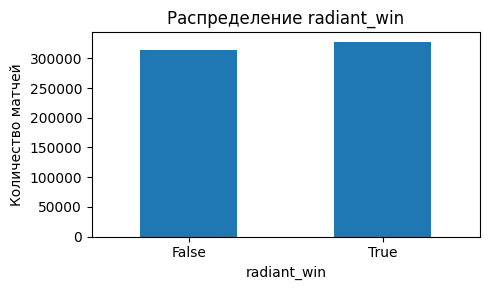

In [3]:
import matplotlib.pyplot as plt

# обычно в этом датасете таргет называется radiant_win
target_col = 'radiant_win'

counts = matches_df_train[target_col].value_counts(dropna=False).sort_index()
share = (counts / counts.sum() * 100).round(2)

print('Распределение(%):')
print(share)

plt.figure(figsize=(5, 3))
counts.plot(kind='bar')
plt.title(f'Распределение {target_col}')
plt.xlabel(target_col)
plt.ylabel('Количество матчей')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:** $\text{Gini}$ подходит больше, потому что классы почти сбалансированы и важно общее качество ранжирования, а $\text{AUC-PR}$ подходит больше при дисбалансе классов.
</div>

#### **Задание 1.2. Категории** (0.75 балла)

Чтобы построить реально балдёжную модель, зачастую не получится просто написать фит предикт. О нет, это долгая и утомительная возня. А если нужно ещё и отчётики писать, то хоть <span style="color:grey"><font size="1">~~вешайся (осуждаем)~~ </font></span> увольняйся. Так и здесь. И того, что есть, уже хватит, чтобы продемонстрировать глубокую и тёмную сторону Dota Science.

В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

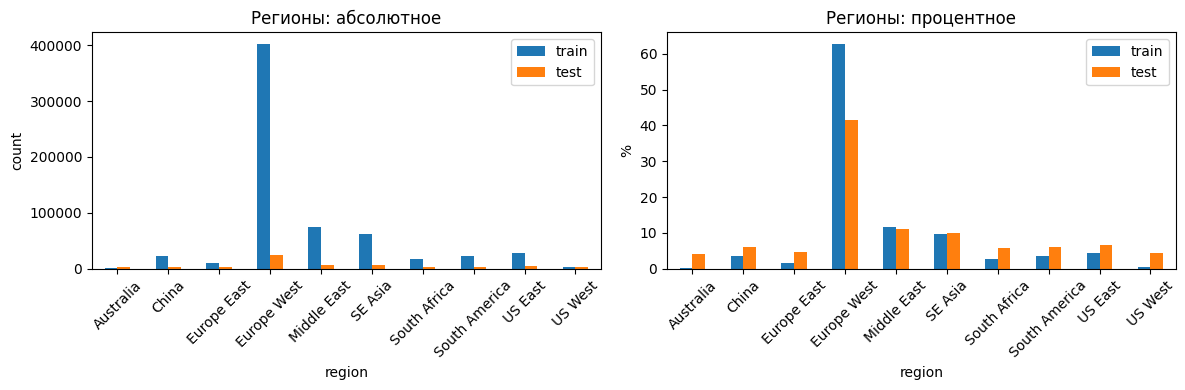

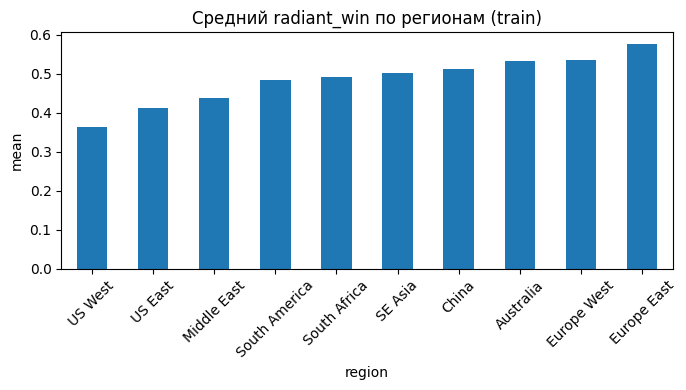

In [4]:
region_col = 'region'
target_col = 'radiant_win'

train_counts = matches_df_train[region_col].value_counts().sort_index()
test_counts = matches_df_test[region_col].value_counts().sort_index()

dist_abs = pd.DataFrame({'train': train_counts, 'test': test_counts}).fillna(0)
dist_pct = dist_abs.div(dist_abs.sum(axis=0), axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dist_abs.plot(kind='bar', ax=axes[0], title='Регионы: абсолютное')
dist_pct.plot(kind='bar', ax=axes[1], title='Регионы: процентное')
axes[0].set_ylabel('count')
axes[1].set_ylabel('%')
for ax in axes:
    ax.set_xlabel('region')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

matches_df_train.groupby(region_col)[target_col].mean().sort_values().plot(kind='bar', figsize=(7, 4))
plt.title('Средний radiant_win по регионам (train)')
plt.xlabel('region')
plt.ylabel('mean')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:** Распределение регионов неравномерное, есть несколько доминирующих регионов, в основном Западная Европа. Средний таргет по регионам отличается, значит слабый сигнал в признаке есть. По одному только региону обучить сильную модель вряд ли получится, но как дополнительный признак его использовать имеет смысл.
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

In [5]:
#!pip install -qU category-encoders

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:** Признаков многовато, как будто One-Hot будет громоздким, поэтому мне больше нравится Target Encoder
</div>

Закодируйте колонку `region` выбранным вами способом

In [6]:
from category_encoders import TargetEncoder

encoder = TargetEncoder(cols=[region_col])
encoder.fit(matches_df_train[[region_col]], matches_df_train[target_col])
matches_df_train[f'{region_col}_encoded'] = encoder.transform(matches_df_train[[region_col]])
matches_df_test[f'{region_col}_encoded'] = encoder.transform(matches_df_test[[region_col]])

#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

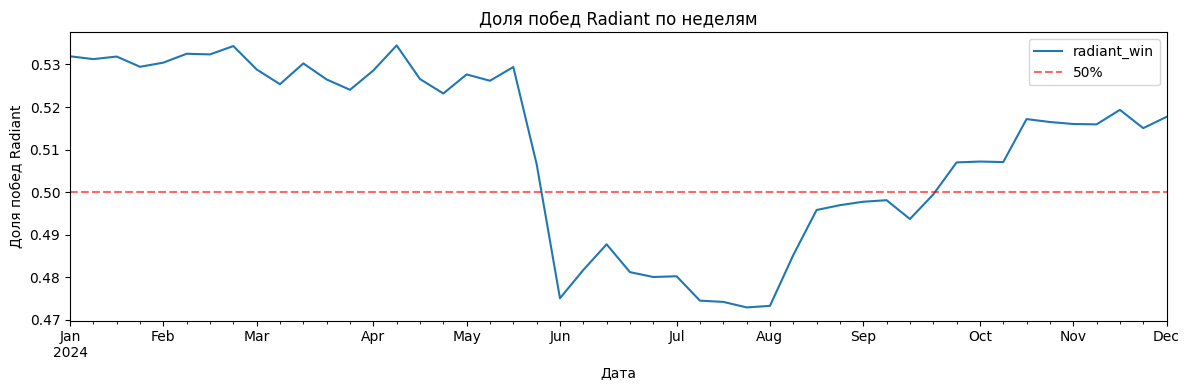

Train: 2024-01-01 00:00:00 — 2024-11-30 00:00:00
Test:  2024-12-01 00:00:00 — 2024-12-31 00:00:00


In [7]:
date_col = 'date'

matches_df_train[date_col] = pd.to_datetime(matches_df_train[date_col])
matches_df_test[date_col] = pd.to_datetime(matches_df_test[date_col])

win_by_date = matches_df_train.set_index(date_col)[target_col].resample('W').mean()

plt.figure(figsize=(12, 4))
win_by_date.plot()
plt.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='50%')
plt.title('Доля побед Radiant по неделям')
plt.xlabel('Дата')
plt.ylabel('Доля побед Radiant')
plt.legend()
plt.tight_layout()
plt.show()

print('Train:', matches_df_train[date_col].min(), '—', matches_df_train[date_col].max())
print('Test: ', matches_df_test[date_col].min(),  '—', matches_df_test[date_col].max())

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:** Да, паттерн такой: в январе–мае 2024 Radiant выигрывал стабильно ~52–53% матчей, затем в конце мая — начале июня произошёл резкий провал до ~47–48%, после чего доля побед постепенно восстанавливалась до ~51–52% к концу года. Я в доту не играю, но мне друг дотер рассказывал летом что вышел какой то жесткий патч перевернувший баланс. Это из того что я нагуглил патч **7.36**, который ввёл систему Facets и Innate Abilities. Видимо новые механики нарушили исторически сложившееся преимущество Radiant потому что привычные тактики, дававшие Radiant лёгкое преимущество, временно перестали работать.

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** День недели и месяц — циклические признаки: воскресенье (6) близко к понедельнику (0), декабрь близок к январю. Линейная модель этого не понимает, поэтому их стоит закодировать через sin/cos-преобразование. День месяца и квартал — порядковые числа, особой цикличности нет, их можно оставить as-is.

</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [8]:
import numpy as np

for df in [matches_df_train, matches_df_test]:
    df['day_of_week'] = df[date_col].dt.dayofweek
    df['day']         = df[date_col].dt.day
    df['month']       = df[date_col].dt.month
    df['quarter']     = df[date_col].dt.quarter
    df['dow_sin']     = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['day_of_week'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

date_features = ['day_of_week', 'day', 'month', 'quarter',
                 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

matches_df_train[[date_col] + date_features].head(3)

,date,day_of_week,day,month,quarter,dow_sin,dow_cos,month_sin,month_cos
0,2024-02-12,0,12,2,1,0.000000,1.00000,8.660254e-01,0.5
1,2024-04-08,0,8,4,2,0.000000,1.00000,8.660254e-01,-0.5
2,2024-06-16,6,16,6,2,-0.781831,0.62349,1.224647e-16,-1.0


Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:** Случайное разбиение здесь плохо подходит, потому что данные зависят от времени: в течение года менялся игровой патч и вместе с ним менялось распределение признаков и таргета. Если перемешать старые и новые матчи, модель на валидации увидит слишком похожие данные на те, что были в обучении, и качество окажется завышенным. Корректнее валидироваться на более позднем промежутке времени, чтобы честно имитировать предсказание будущих матчей.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [9]:
valid_start = pd.Timestamp('2024-11-01')

train_mask = matches_df_train[date_col] < valid_start
valid_mask = matches_df_train[date_col] >= valid_start

y_train = matches_df_train.loc[train_mask, target_col]
y_valid = matches_df_train.loc[valid_mask, target_col]

print('Train period:', matches_df_train.loc[train_mask, date_col].min(), '—', matches_df_train.loc[train_mask, date_col].max())
print('Valid period:', matches_df_train.loc[valid_mask, date_col].min(), '—', matches_df_train.loc[valid_mask, date_col].max())
print('Train size:', train_mask.sum())
print('Valid size:', valid_mask.sum())


Train period: 2024-01-01 00:00:00 — 2024-10-31 00:00:00
Valid period: 2024-11-01 00:00:00 — 2024-11-30 00:00:00
Train size: 582297
Valid size: 58793


И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [10]:
from sklearn.linear_model import LogisticRegression

date_feature_cols = date_features
region_feature_cols = ['region_encoded']
date_region_feature_cols = date_feature_cols + region_feature_cols

for name, cols in [
    ('dates',         date_feature_cols),
    ('regions',       region_feature_cols),
    ('dates+regions', date_region_feature_cols),
]:
    X_tr  = matches_df_train.loc[train_mask, cols]
    X_val = matches_df_train.loc[valid_mask, cols]
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_train)
    print(f"{name}: train={gini(y_train, model.predict_proba(X_tr)[:, 1]):.4f}, "
          f"valid={gini(y_valid, model.predict_proba(X_val)[:, 1]):.4f}")


dates: train=0.0440, valid=-0.0010
regions: train=0.0756, valid=0.0760
dates+regions: train=0.0959, valid=0.0755


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:** В текущем виде даты скорее не помогли, модель только на датах дала почти нулевой Gini на валидации, а добавление дат к регионам даже слегка ухудшило качество относительно модели только на регионах. В теории временной сигнал может быть (патчи и мета меняются), но выбранные простые календарные признаки его, видимо, не уловили достаточно хорошо. На этом этапе я бы лучше даты не оставлял в базовом наборе

</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

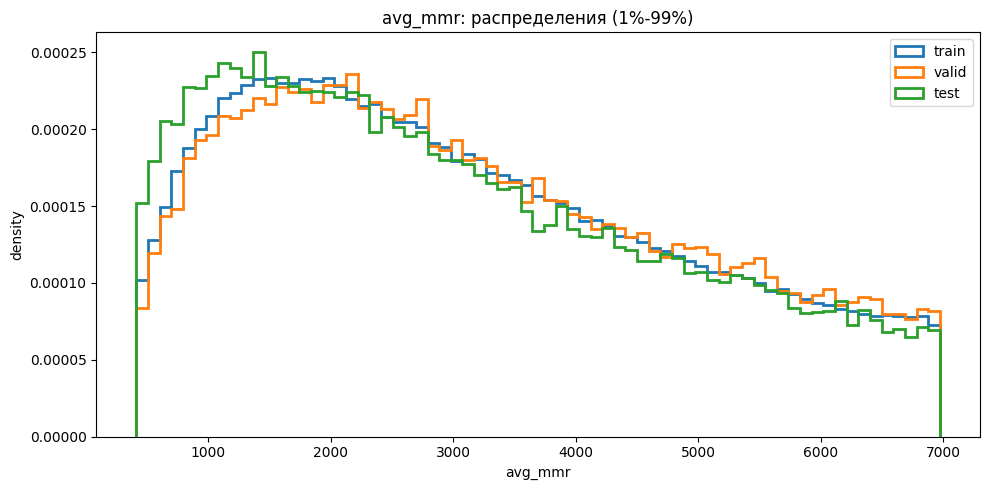

In [11]:
mmr_col = 'avg_mmr'

train_mmr = matches_df_train.loc[train_mask, mmr_col].dropna()
valid_mmr = matches_df_train.loc[valid_mask, mmr_col].dropna()
test_mmr = matches_df_test[mmr_col].dropna()

all_mmr = pd.concat([train_mmr, valid_mmr, test_mmr], axis=0)
left, right = all_mmr.quantile([0.01, 0.99])
bins = np.linspace(left, right, 70)

plt.figure(figsize=(10, 5))
plt.hist(train_mmr, bins=bins, density=True, histtype='step', linewidth=2, label='train')
plt.hist(valid_mmr, bins=bins, density=True, histtype='step', linewidth=2, label='valid')
plt.hist(test_mmr, bins=bins, density=True, histtype='step', linewidth=2, label='test')
plt.title('avg_mmr: распределения (1%-99%)')
plt.xlabel('avg_mmr')
plt.ylabel('density')
plt.legend()
plt.tight_layout()
plt.show()


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:** Распределение одномодальное и заметно скошено вправо, основная масса матчей сосредоточена в зоне средних значений MMR, а дальше тянется длинный правый хвост к большим значениям. По форме оно похоже на логнормальное распределение, Train/valid/test визуально очень похожи, различия в хвостах небольшие.

</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

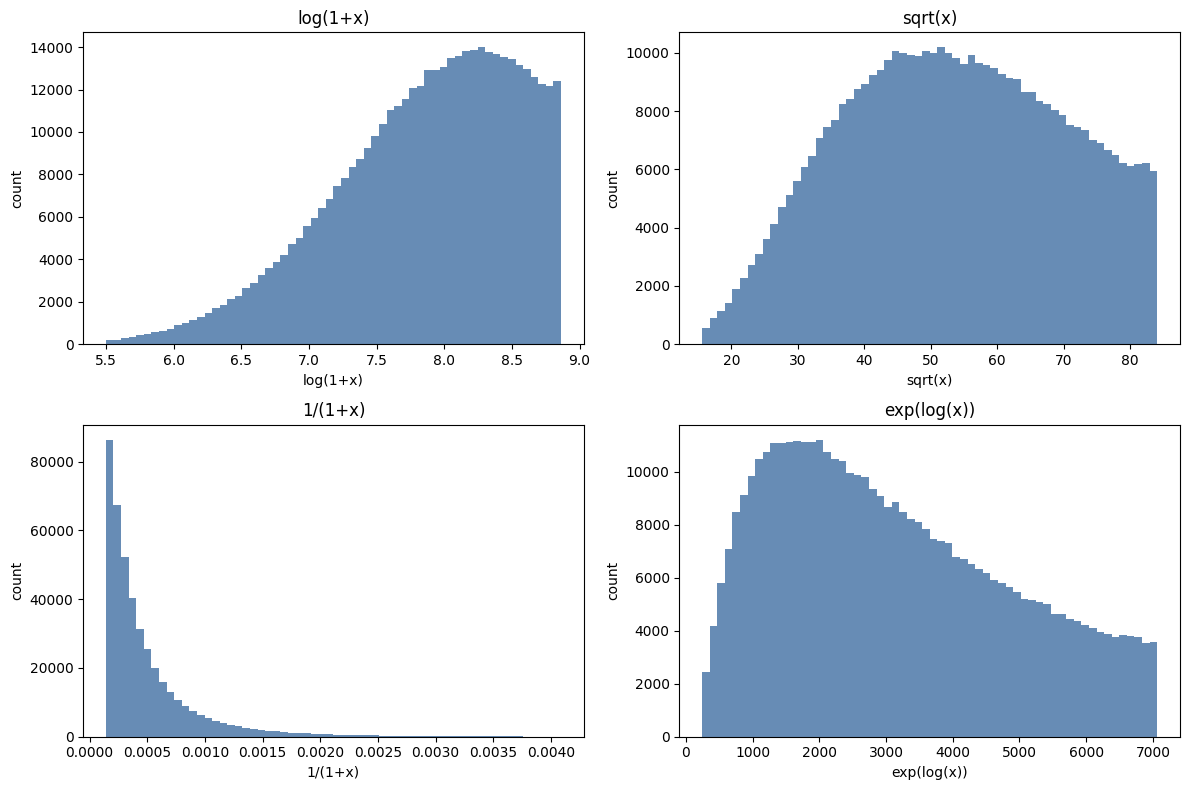

Chosen transform: log(1+x)


In [12]:
mmr_col = 'avg_mmr'
mmr_train = matches_df_train.loc[train_mask, mmr_col].dropna()

mmr_transforms = {
    'log(1+x)': np.log1p(mmr_train),
    'sqrt(x)': np.sqrt(mmr_train),
    '1/(1+x)': 1.0 / (1.0 + mmr_train),
    'exp(log(x))': np.exp(np.log(mmr_train)),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, values) in zip(axes.ravel(), mmr_transforms.items()):
    ax.hist(values, bins=60, color='#4C78A8', alpha=0.85)
    ax.set_title(name)
    ax.set_xlabel(name)
    ax.set_ylabel('count')

plt.tight_layout()
plt.show()

chosen_mmr_transform = 'log(1+x)'
print('Chosen transform:', chosen_mmr_transform)


Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:** Нулём заполнять идея не оч, 0 для MMR это не обычное значение, встречающееся в игре и оно создаёт искусственный кластер, который искажает распределение. Лучше заполнять устойчивой статистикой, например медианой по train и просто добавить флаг `mmr_missing`, чтобы модель отдельно учитывала сам факт пропуска.

</div>

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [13]:
mmr_fill_value = matches_df_train.loc[train_mask, 'avg_mmr'].median()

X_train_raw = matches_df_train.loc[train_mask, ['region_encoded']].copy()
X_valid_raw = matches_df_train.loc[valid_mask, ['region_encoded']].copy()
X_train_raw['avg_mmr'] = matches_df_train.loc[train_mask, 'avg_mmr'].fillna(mmr_fill_value)
X_valid_raw['avg_mmr'] = matches_df_train.loc[valid_mask, 'avg_mmr'].fillna(mmr_fill_value)

X_train_transformed = matches_df_train.loc[train_mask, ['region_encoded']].copy()
X_valid_transformed = matches_df_train.loc[valid_mask, ['region_encoded']].copy()
X_train_transformed['avg_mmr'] = np.log1p(matches_df_train.loc[train_mask, 'avg_mmr'].fillna(mmr_fill_value))
X_valid_transformed['avg_mmr'] = np.log1p(matches_df_train.loc[valid_mask, 'avg_mmr'].fillna(mmr_fill_value))

for name, X_tr, X_val in [
    ('raw_mmr', X_train_raw, X_valid_raw),
    ('log_mmr', X_train_transformed, X_valid_transformed),
]:
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_train)
    print(f"{name}: train={gini(y_train, model.predict_proba(X_tr)[:, 1]):.4f}, valid={gini(y_valid, model.predict_proba(X_val)[:, 1]):.4f}")


raw_mmr: train=0.1114, valid=0.1088
log_mmr: train=0.1171, valid=0.1141


### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">

В которой студент испытывает вьетнамские флешбеки от дз1, фиксит чужие баги и делает нереально мощную фичу, которую можно полировать до посинения

#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [14]:
if 'player_df' not in globals():
    player_df = pd.read_csv('player_df.csv')

suspicious_ids = [4294967295, -1]
print('Подозрительные account_id:', suspicious_ids)

scope_match_ids = pd.Index(matches_df_train['match_id']).union(matches_df_test['match_id'])
scope_player = player_df[player_df['match_id'].isin(scope_match_ids)]

bad_match_ids = scope_player.loc[
    scope_player['account_id'].isin(suspicious_ids),
    'match_id'
].unique()

n_scope_matches = scope_match_ids.nunique()
n_bad_matches = len(bad_match_ids)
share_bad = n_bad_matches / n_scope_matches * 100

print(f"Матчей с подозрительными account_id: {n_bad_matches} ({share_bad:.2f}%)")

Подозрительные account_id: [4294967295, -1]
Матчей с подозрительными account_id: 637986 (91.03%)


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:** Нет, не можем, подозрительные `account_id` встречаются в 91.03% матчей из train+test, так что если такие матчи удалить, мы получается потеряем почти весь датасет
</div>

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [15]:
dup_hero_matches = (
    player_df.groupby('match_id')['hero_id']
    .nunique()
    .loc[lambda s: s < 10]
    .index
)

player_df = player_df[~player_df['match_id'].isin(dup_hero_matches)].copy()
print('player_df shape после удаления:', player_df.shape)

player_df shape после удаления: (7638410, 14)


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [16]:
suspicious_ids = [4294967295, -1]
scope_match_ids = pd.Index(matches_df_train['match_id']).union(matches_df_test['match_id'])

hero0_rows = player_df[player_df['hero_id'] == 0][['match_id', 'account_id', 'player_slot', 'hero_id']]
hero0_matches = hero0_rows['match_id'].unique()
player_df = player_df[~player_df['match_id'].isin(hero0_matches)].copy()

side_df = player_df[~player_df['account_id'].isin(suspicious_ids)].copy()
side_df = side_df[side_df['player_slot'].isin(list(range(5)) + list(range(128, 133)))]
side_df['side'] = side_df['player_slot'].apply(lambda x: 'radiant' if x < 5 else 'dire')

bad_pairs = (
    side_df.groupby(['match_id', 'account_id'])['side']
    .nunique()
    .loc[lambda s: s > 1]
    .reset_index()[['match_id', 'account_id']]
)

if len(bad_pairs) > 0:
    player_df = player_df.merge(bad_pairs.assign(_bad=1), on=['match_id', 'account_id'], how='left')
    player_df = player_df[player_df['_bad'].isna()].drop(columns=['_bad'])

player_df = player_df[player_df['match_id'].isin(scope_match_ids)].copy()

radiant_counts = player_df['player_slot'].isin(range(5)).groupby(player_df['match_id']).sum()
dire_counts = player_df['player_slot'].isin(range(128, 133)).groupby(player_df['match_id']).sum()
bad_balance_matches = ((radiant_counts != 5) | (dire_counts != 5))

bad_balance_match_ids = bad_balance_matches[bad_balance_matches].index
player_df = player_df[~player_df['match_id'].isin(bad_balance_match_ids)].copy()

Если вас всё же одолевает паранойя, то ~~я вас понимаю~~ будьте уверены, что если проблемы в `player_df` и остались, на модель они повлияют минимально. Ну а идеала не бывает нигде

#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [17]:
from scipy.sparse import csr_array  # вам может понравиться

class HeroesEncoder:

    def fit(self, X, y=None):
        self.hero_ids_ = np.sort(player_df['hero_id'].unique())
        self.hero_to_col_ = {hero_id: i for i, hero_id in enumerate(self.hero_ids_)}
        return self

    def transform(self, X, y=None):
        match_ids = X['match_id'].to_numpy()
        row_map = {match_id: i for i, match_id in enumerate(match_ids)}

        part = player_df[player_df['match_id'].isin(match_ids)][['match_id', 'hero_id', 'player_slot']]

        rows, cols, data = [], [], []
        for match_id, hero_id, player_slot in part.itertuples(index=False):
            col = self.hero_to_col_.get(hero_id)
            if col is None:
                continue
            rows.append(row_map[match_id])
            cols.append(col)
            data.append(1 if player_slot < 5 else -1)

        rows = np.asarray(rows, dtype=np.int32)
        cols = np.asarray(cols, dtype=np.int32)
        data = np.asarray(data, dtype=np.int8)

        return csr_array((data, (rows, cols)), shape=(len(match_ids), len(self.hero_ids_)))

Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [18]:
import numpy as np
from scipy.sparse import hstack, csr_array
from sklearn.linear_model import LogisticRegression

required = ['matches_df_train', 'train_mask', 'valid_mask', 'y_train', 'y_valid', 'player_df', 'gini', 'HeroesEncoder']
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(f"Run previous cells first. Missing: {missing}")

def to_int32_csr_array(x):
    return csr_array((x.data, x.indices.astype(np.int32), x.indptr.astype(np.int32)), shape=x.shape)

encoder = HeroesEncoder().fit(matches_df_train[['match_id']])

X_train_heroes = to_int32_csr_array(encoder.transform(matches_df_train.loc[train_mask, ['match_id']]))
X_valid_heroes = to_int32_csr_array(encoder.transform(matches_df_train.loc[valid_mask, ['match_id']]))

all_feature_cols = [
    'region_encoded',
    'day_of_week', 'day', 'month', 'quarter',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
]

mmr_fill_value = matches_df_train.loc[train_mask, 'avg_mmr'].median()
X_train_base = matches_df_train.loc[train_mask, all_feature_cols].copy()
X_valid_base = matches_df_train.loc[valid_mask, all_feature_cols].copy()
X_train_base['avg_mmr_log'] = np.log1p(matches_df_train.loc[train_mask, 'avg_mmr'].fillna(mmr_fill_value))
X_valid_base['avg_mmr_log'] = np.log1p(matches_df_train.loc[valid_mask, 'avg_mmr'].fillna(mmr_fill_value))

X_train_all = to_int32_csr_array(hstack([csr_array(X_train_base.to_numpy()), X_train_heroes], format='csr'))
X_valid_all = to_int32_csr_array(hstack([csr_array(X_valid_base.to_numpy()), X_valid_heroes], format='csr'))

model_all = LogisticRegression(max_iter=1000, solver='liblinear')
model_all.fit(X_train_all, y_train)

model_heroes = LogisticRegression(max_iter=1000, solver='liblinear')
model_heroes.fit(X_train_heroes, y_train)

print(f"all_features: train={gini(y_train, model_all.predict_proba(X_train_all)[:, 1]):.4f}, valid={gini(y_valid, model_all.predict_proba(X_valid_all)[:, 1]):.4f}")
print(f"heroes_only:  train={gini(y_train, model_heroes.predict_proba(X_train_heroes)[:, 1]):.4f}, valid={gini(y_valid, model_heroes.predict_proba(X_valid_heroes)[:, 1]):.4f}")

all_features: train=0.2995, valid=0.2949
heroes_only:  train=0.2723, valid=0.2713


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [19]:
import optuna
from sklearn.linear_model import LogisticRegression


def objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e2, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        'max_iter': trial.suggest_int('max_iter', 200, 600),
        'random_state': 42,
    }

    model = LogisticRegression(**params)
    model.fit(X_train_all, y_train)

    gini_valid = gini(y_valid, model.predict_proba(X_valid_all)[:, 1])
    return gini_valid


study = optuna.create_study(direction="maximize")
study.optimize(objective, show_progress_bar=True, n_trials=8, timeout=60)

print('Best params:', study.best_params)
print(f"Best valid gini: {study.best_value:.4f}")

c:\Users\Amir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-16 19:47:55,457] A new study created in memory with name: no-name-d618e188-fe9a-4c9a-a69c-d36cd5bdc0c5
  0%|          | 0/8 [00:00<?, ?it/s]c:\Users\Amir\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 263 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=263).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-reg

[I 2026-03-16 19:48:04,918] Trial 0 finished with value: 0.29438657462982665 and parameters: {'C': 0.0206489423582823, 'solver': 'lbfgs', 'max_iter': 263}. Best is trial 0 with value: 0.29438657462982665.


Best trial: 1. Best value: 0.294875:  25%|██▌       | 2/8 [00:14<00:40,  6.82s/it, 14.44/60 seconds]

[I 2026-03-16 19:48:09,895] Trial 1 finished with value: 0.2948754400725577 and parameters: {'C': 0.3791013465587479, 'solver': 'liblinear', 'max_iter': 398}. Best is trial 1 with value: 0.2948754400725577.


Best trial: 1. Best value: 0.294875:  38%|███▊      | 3/8 [00:27<00:47,  9.45s/it, 27.02/60 seconds]

...

[I 2026-03-16 19:48:44,438] Trial 5 finished with value: 0.2948686030042622 and parameters: {'C': 0.2682933270318602, 'solver': 'liblinear', 'max_iter': 525}. Best is trial 1 with value: 0.2948754400725577.


Best trial: 1. Best value: 0.294875:  88%|████████▊ | 7/8 [00:58<00:08,  8.10s/it, 58.54/60 seconds]

[I 2026-03-16 19:48:54,000] Trial 6 finished with value: 0.2935407474963756 and parameters: {'C': 0.008877733828271296, 'solver': 'lbfgs', 'max_iter': 277}. Best is trial 1 with value: 0.2948754400725577.


Best trial: 1. Best value: 0.294875: 100%|██████████| 8/8 [01:08<00:00,  8.54s/it, 68.32/60 seconds]

[I 2026-03-16 19:49:03,773] Trial 7 finished with value: 0.2919952016801348 and parameters: {'C': 0.004911285095669056, 'solver': 'lbfgs', 'max_iter': 590}. Best is trial 1 with value: 0.2948754400725577.
Best params: {'C': 0.3791013465587479, 'solver': 'liblinear', 'max_iter': 398}
Best valid gini: 0.2949


#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

C:\Users\Amir\AppData\Local\Temp\ipykernel_25780\345250711.py:4: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


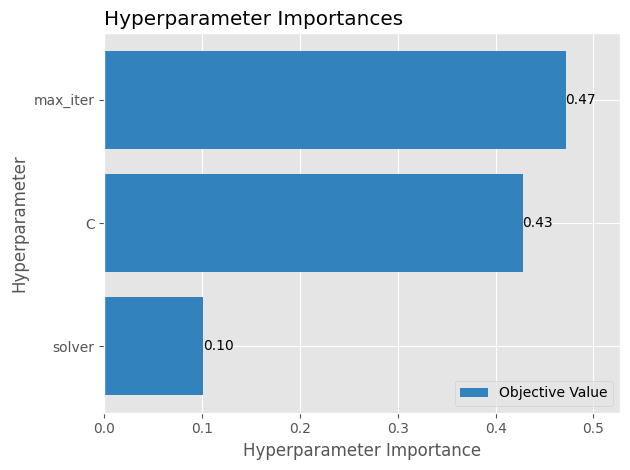

In [20]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_param_importances

plot_param_importances(study)
plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:** В моём быстром подборе сильнее всего влияет `C`, потому что именно он напрямую регулирует силу регуляризации и сильнее всего меняет качество. `max_iter` и `solver` обычно оказываются менее важными, если итераций уже хватает для сходимости, а оба солвера дают близкий результат, вклад этих параметров меньше

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [21]:
import joblib
import pandas as pd

best_params = study.best_params.copy()
best_params['random_state'] = 42

final_encoder = HeroesEncoder().fit(matches_df_train[['match_id']])

X_full_heroes = to_int32_csr_array(final_encoder.transform(matches_df_train[['match_id']]))
X_test_heroes = to_int32_csr_array(final_encoder.transform(matches_df_test[['match_id']]))

X_full_base = matches_df_train[all_feature_cols].copy()
X_test_base = matches_df_test[all_feature_cols].copy()

full_mmr_fill_value = matches_df_train['avg_mmr'].median()
X_full_base['avg_mmr_log'] = np.log1p(matches_df_train['avg_mmr'].fillna(full_mmr_fill_value))
X_test_base['avg_mmr_log'] = np.log1p(matches_df_test['avg_mmr'].fillna(full_mmr_fill_value))

X_full_all = to_int32_csr_array(hstack([csr_array(X_full_base.to_numpy()), X_full_heroes], format='csr'))
X_test_all = to_int32_csr_array(hstack([csr_array(X_test_base.to_numpy()), X_test_heroes], format='csr'))

final_model = LogisticRegression(**best_params)
final_model.fit(X_full_all, matches_df_train[target_col])

joblib.dump(final_model, 'final_model.joblib')

submission = pd.DataFrame({
    'ID': matches_df_test['match_id'],
    'Value': final_model.predict_proba(X_test_all)[:, 1],
})
submission.to_csv('submission.csv', index=False)

best_params

{'C': 0.3791013465587479,
 'solver': 'liblinear',
 'max_iter': 398,
 'random_state': 42}